<div style="width:100%; text-align:center; padding:10px 0;">
<img src="project_header.png" style="width:100%; max-width:100vw; height:auto; display:block; margin:0 auto;">
</div>

# EO Africa SWAM project 
## Create Chla data cube and timeseries

In this notebook we stack all the estimated Chla results and create a data cube containing the Chla timeseries 

#### This notebook does the following:
* creates a list of Chla nc output files to process
* Filter images by the number of valid pixels
* Do statistics to get the 10%, median, mean and 90% values for each image
* Plot the median Chla map
* Saves output to netcdf and csv

#### Requirements: 
* Make sure that you have already created some "_chl_.nc" output files using the *Chl_Step4_reproject_clip.ipynb* notebook.

### Version history:
* Version 1.0, 26 Feb 2026

##### Authors:
**Dalin Jiang**, University of Stirling, UK; **Marie Smith**, CSIR, South Africa 

In [6]:
import glob
import os
from datetime import datetime
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as colors
import re

## Step 1: Search for the Chla files for one lake
set up the following:
* input path: the Chla results of each date separately
* output path: where the results of data cube and timeseries will be saved

In [4]:
# set up the input and output path

input_dir = "/"+lake_name+"_chl/"
#in_path = "/home/eoafrica/shared/SWAM/final_processing/CHL/MDN/TW/"

all_img = sorted(glob.glob(in_path+'*.nc'))
lake_name = os.path.basename(all_img[0]).split("_")[4]
print(f'found {len(all_img)} images, with the first 5 showing below:')
all_img[0:5]

found 540 images, with the first 5 showing below:


['/home/eoafrica/shared/SWAM/final_processing/CHL/MDN/TW/S2A_20150810T084949_T34HCH_ACO_TW_CHL.nc',
 '/home/eoafrica/shared/SWAM/final_processing/CHL/MDN/TW/S2A_20151019T084955_T34HCH_ACO_TW_CHL.nc',
 '/home/eoafrica/shared/SWAM/final_processing/CHL/MDN/TW/S2A_20151208T084949_T34HCH_ACO_TW_CHL.nc',
 '/home/eoafrica/shared/SWAM/final_processing/CHL/MDN/TW/S2A_20151218T084949_T34HCH_ACO_TW_CHL.nc',
 '/home/eoafrica/shared/SWAM/final_processing/CHL/MDN/TW/S2A_20151228T084950_T34HCH_ACO_TW_CHL.nc']

In [7]:
def extract_time_from_filename(filename):
    match = re.search(r'_(\d{8}T\d{6})_', filename)
    if match:
        date_str = match.group(1)
        return pd.to_datetime(date_str, format="%Y%m%dT%H%M%S")
    else:
        raise ValueError(f"Couldn't parse datetime from filename {filename}")

# Create list of (filepath, time) tuples
files_with_time = [(f, extract_time_from_filename(os.path.basename(f))) for f in all_img]

# Sort by extracted time
files_with_time_sorted = sorted(files_with_time, key=lambda x: x[1])

# Separate sorted filepaths and time
sorted_file_list = [f[0] for f in files_with_time_sorted]
sorted_times = [f[1] for f in files_with_time_sorted]

In [8]:
# Open datasets, expand dims with time, concatenate
data_arrays = []
for f, t in zip(sorted_file_list, sorted_times):
    ds = xr.open_dataset(f)
    chla = ds['CHL']
    data_arrays.append(chla)

ds = xr.concat(data_arrays, dim='time')

sdate = ds.time.dt.strftime('%Y-%m-%d').isel(time=0).item()
edate = ds.time.dt.strftime('%Y-%m-%d').isel(time=-1).item()

## Step 2: Filter images by the number of valid pixels
This processing will filter the data using the number of valid pixels of each image, i.e., these images with less than a certain number of valid pixels (here 5%) will be excluded to avoid outliers.

In [9]:
# Step 1: Calculate valid water pixels count per day
valid_pixels_per_day = ds.notnull().sum(dim=['lat', 'lon'])
max_water = valid_pixels_per_day.max().values

# Step 2: Total pixels per image
total_pixels = ds.sizes['lat'] * ds.sizes['lon']

# Step 3: Define threshold for minimum 5% valid water pixels
threshold = 0.05 * max_water

# Step 4: Create mask to select only days where valid pixels >= threshold
valid_days_mask = valid_pixels_per_day >= threshold

# Step 5: Filter data to those valid days
ds_valid = ds.sel(time=valid_days_mask)
num_ts = ds_valid.notnull().sum(dim=['lat','lon'])

print(f' number of valid images after filtering: {num_ts.shape}')

 number of valid images after filtering: (491,)


## Step 3: Calculate the 10%, mean, median and 90% values of each image
This processing will calcualte the 10%, mean, median and 90% values of Chla for each image, this results in a Chla timeseries, results will be exported to a csv file

In [10]:
# calculate the median, 10% and 90% data, as well as monthly median data

p10_ts = ds_valid.reduce(np.nanpercentile, q=10, dim=['lat', 'lon'])               # 10% of all valid images, timeseries
p90_ts = ds_valid.reduce(np.nanpercentile, q=90, dim=['lat', 'lon'])               # 90% of all valid images, timeseries
median_ts = ds_valid.median(dim=['lat', 'lon'], skipna=True)                       # median of all valid images, timeseries
mean_ts = ds_valid.mean(dim=['lat', 'lon'], skipna=True)                           # mean of all valid images, timeseries

median_map = ds_valid.median(dim=['time'], skipna=True)                            # median of all valid images, map
monthly_median = ds_valid.groupby('time.month').median(dim=['time'], skipna=True)  # monthly median of all valid images

## Step 4: Plot the median Chla map

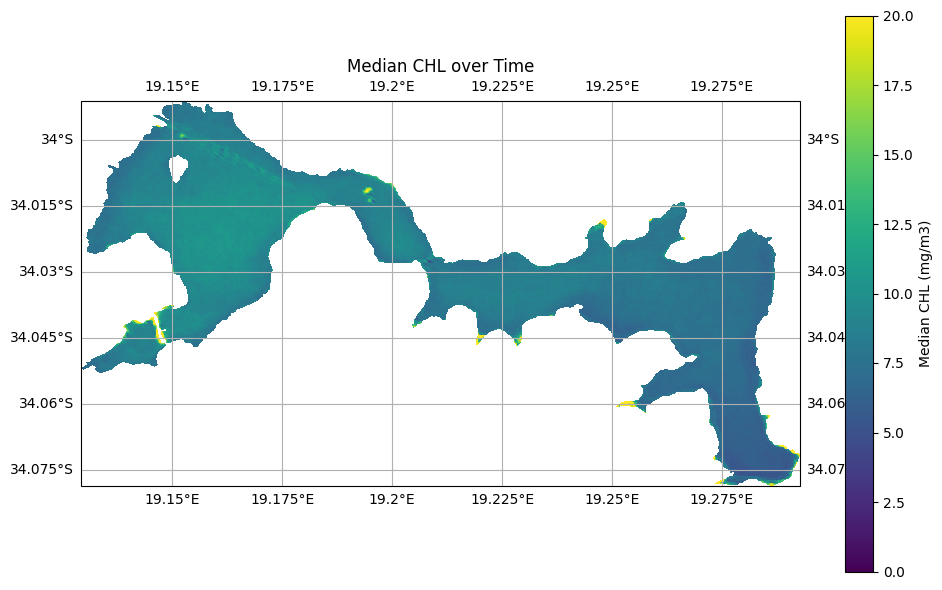

In [13]:
# plot the median CHL map
#
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot median CHL as colored raster
img = ax.pcolormesh(median_map['lon'], median_map['lat'], median_map, 
                    shading='auto', cmap='viridis', vmin=0, vmax=20, transform=ccrs.PlateCarree())

ax.coastlines()
ax.gridlines(draw_labels=True)

cbar = fig.colorbar(img, ax=ax, orientation='vertical', label='Median CHL (mg/m3)')

plt.title('Median CHL over Time')
plt.tight_layout()
# plt.savefig(lake_name+'_median_CHL_alltime_over_validpix05.png',dpi=300)  # uncomment this line to export the figure

plt.show()

## Step 5: Plot the Chla time series

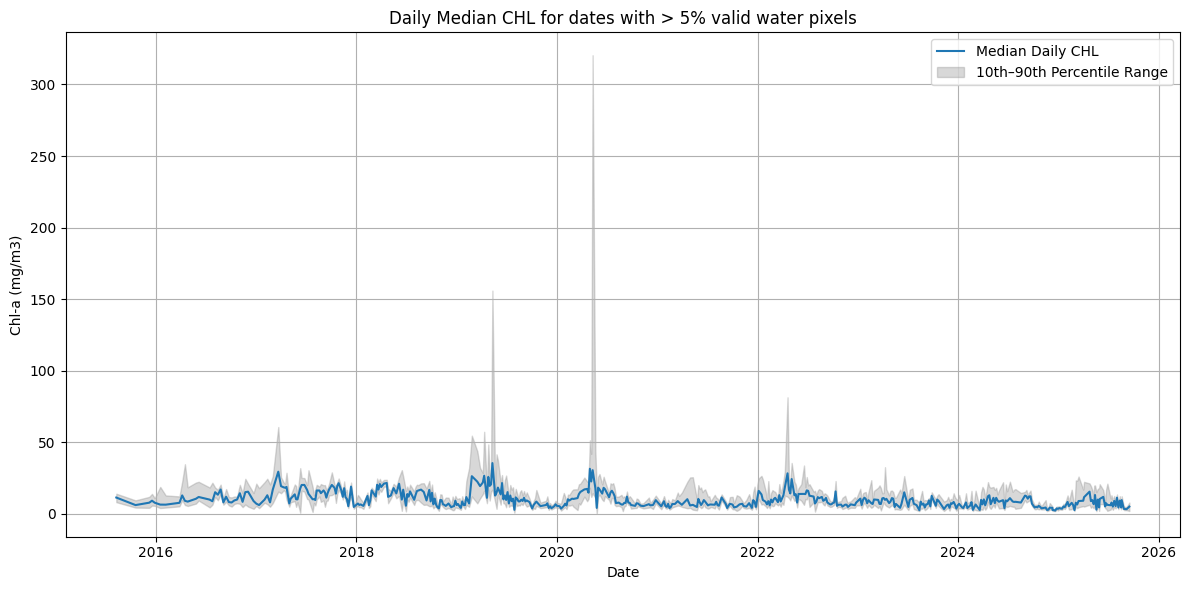

In [14]:
# Plot timeseries with shaded percentile range
plt.figure(figsize=(12, 6))
plt.plot(median_ts['time'], median_ts, label='Median Daily CHL')
plt.fill_between(median_ts['time'], p10_ts, p90_ts, color='gray', alpha=0.3,
                 label='10th–90th Percentile Range')
plt.xlabel('Date')
plt.ylabel('Chl-a (mg/m3)')
plt.title(f'Daily Median CHL for dates with > 5% valid water pixels')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(lake_name+'_daily_median_percentiles_chl_over_time_validpix05.png',dpi=300)  # uncomment this line to export the figure

plt.show()

## Step 6: Export results
The following reults will be exported:
* the statistics of CHL in Step 3 to a csv file
* the data cube, which is a 3D data (lat x lon x time) including all CHL data

In [21]:
# export results to disk: 

# 1. Chl-a data cube
aa,bb,cc = ds.shape

ds = ds.chunk({"time":10,"lat":bb, "lon":cc})
ds.attrs = {'Product': 'Chlorophyll-a concentration',
            'Units': 'mg m-3',
            'Sensor': 'Sentinel-2 MSI',
            'AC Algorithm': 'ACOLITE-RAdCor',
            'AC Algorithm DOI': 'https://doi.org/10.1364/AO.546766',
            'Chl Algorithm': 'Mixture Density Network v3',
            'Chl Algorithm DOI': 'https://doi.org/10.1016/j.rse.2019.111604',
            'Project': 'ESA EO Africa R&D SWAM',
            'Project PI': 'Marie Smith, CSIR; Dalin Jiang, University of Stirling',
            'PI Contact':'msmith2@csir.co.za; dalin.jiang@stir.ac.uk',
            'History': str(datetime.utcnow()) + ' Python',
            'Startdate':sdate,
            'Enddate':edate,
            'Lake_name':lake_name,
            'Lake_location':'Western Cape, South Africa',
            'Min_Latitude':ds.lat.min().item(),
            'Max_Latitude':ds.lat.max().item(),
            'Min_Longitude':ds.lon.min().item(),
            'Max_Longitude':ds.lon.max().item(),
            }

comp = dict(zlib=True, complevel=6, dtype='float32')  # 1–9 (higher = more compression, slower)
encoding = {ds.name: comp}  # Use ds.name ('chl' or whatever your variable is called)

out_cube_file = "CHL_cube_2015_2025_"+lake_name+".nc"
ds.to_netcdf(out_cube_file,format='NETCDF4', encoding=encoding) # engine="h5netcdf" for faster writing

/tmp/ipykernel_1158994/2592765876.py:32: UserWarning: Times can't be serialized faithfully to int64 with requested units 'days since 2015-08-10T08:49:49'. Serializing with units 'seconds since 2015-08-10T08:49:49' instead. Set encoding['dtype'] to floating point dtype to serialize with units 'days since 2015-08-10T08:49:49'. Set encoding['units'] to 'seconds since 2015-08-10T08:49:49' to silence this warning .
  ds.to_netcdf(out_cube_file,format='NETCDF4', encoding=encoding) # engine="h5netcdf" for faster writing


In [24]:
# merge all statistics, assume all data have the same order by time
mg_dt = xr.merge([p10_ts.rename("CHL_10P"), 
                  mean_ts.rename("CHL_mean"),
                  median_ts.rename("CHL_median"),
                  p90_ts.rename("CHL_90P"),
                  num_ts.rename("N_valid")])

# convert to dataframe
tmp_df = mg_dt.to_dataframe()

# add time and lake information
#tmp_df["Date"] = tmp_df.index.map(lambda x: datetime.date(x))
tmp_df["Date"] = tmp_df.index.map(lambda x: x.date())
tmp_df["DateTime_UTC"] = tmp_df.index
tmp_df["Lake_name"] = lake_name

# reorder the data
ts_df = tmp_df[["Lake_name","DateTime_UTC","Date", "CHL_10P","CHL_mean","CHL_median","CHL_90P","N_valid"]]

# export the data to a csv
out_ts_file = "CHL_timeseries_2015_2025_"+lake_name+".csv"
ts_df.to_csv(out_ts_file, index=False)